In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [38]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML2.2%20real%20classification/data/diabetes.csv")

In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
y = data.Outcome
X = data.drop(["Outcome"], axis=1)

In [8]:
y.shape, X.shape

((768,), (768, 8))

In [9]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()

In [10]:
logistic.fit(X, y)

/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
print("Coefficients: \n", logistic.coef_[0])

Coefficients: 
 [ 1.17252349e-01  3.35999360e-02 -1.40873517e-02 -1.27044650e-03
 -1.24032666e-03  7.72022359e-02  1.41904207e+00  1.00352768e-02]


In [12]:
_ = [print(k, v) for k, v in zip(X.columns, logistic.coef_[0])]

Pregnancies 0.11725234881485337
Glucose 0.03359993600310737
BloodPressure -0.014087351650985541
SkinThickness -0.001270446504247434
Insulin -0.0012403266574180925
BMI 0.07720223590571074
DiabetesPedigreeFunction 1.4190420652026108
Age 0.010035276824940485


In [13]:
print("Intercept: \n", logistic.intercept_)

Intercept: 
 [-7.70292164]


In [14]:
y_pred = logistic.predict(X)

In [15]:
_ = [print(a, b) for a, b in list(zip(y, y_pred))[:10]]

1 1
0 0
1 1
0 0
1 1
0 0
1 0
0 1
1 1
1 0


In [16]:
from sklearn import metrics
metrics.confusion_matrix(y, y_pred)

array([[447,  53],
       [114, 154]])

<Axes: >

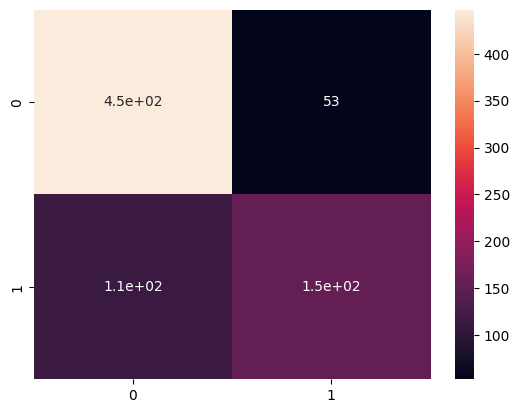

In [17]:
import seaborn as sns
sns.heatmap(metrics.confusion_matrix(y, y_pred), annot=True)

In [18]:
logistic.score(X, y)

0.7825520833333334

In [20]:
metrics.accuracy_score(y, y_pred)

0.7825520833333334

In [21]:
from sklearn.preprocessing import PolynomialFeatures

In [43]:
poly = PolynomialFeatures(2)

In [44]:
poly = poly.fit_transform(X)
poly

array([[1.00000e+00, 6.00000e+00, 1.48000e+02, ..., 3.93129e-01,
        3.13500e+01, 2.50000e+03],
       [1.00000e+00, 1.00000e+00, 8.50000e+01, ..., 1.23201e-01,
        1.08810e+01, 9.61000e+02],
       [1.00000e+00, 8.00000e+00, 1.83000e+02, ..., 4.51584e-01,
        2.15040e+01, 1.02400e+03],
       ...,
       [1.00000e+00, 5.00000e+00, 1.21000e+02, ..., 6.00250e-02,
        7.35000e+00, 9.00000e+02],
       [1.00000e+00, 1.00000e+00, 1.26000e+02, ..., 1.21801e-01,
        1.64030e+01, 2.20900e+03],
       [1.00000e+00, 1.00000e+00, 9.30000e+01, ..., 9.92250e-02,
        7.24500e+00, 5.29000e+02]], shape=(768, 45))

In [45]:
polynomial = LogisticRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

## Практическая работа 

### 0. Точность модели и сравнение с линейной 

In [46]:
polynomial.score(poly, y)

0.7239583333333334

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
linear = LinearRegression()

In [32]:
linear.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
linear.score(X, y)

0.303253095650892

### 1. Какую информацию еще можно вывести и изменение аргументов

In [47]:
print(f"Коэффициенты (coef_): {polynomial.coef_}")

Коэффициенты (coef_): [[-6.32938534e-06 -5.18413402e-06 -3.92246551e-04 -1.99973701e-04
  -6.12212930e-05 -2.09427712e-04 -9.52741139e-05 -8.26831151e-07
  -9.79925951e-05  6.40141550e-05  4.86392513e-04  4.87675349e-04
   1.15333672e-04  1.39813115e-04  1.62168696e-04  6.83260650e-06
   9.44930509e-05  1.22278302e-04  6.37067088e-05  4.28557232e-06
  -3.74909055e-05  1.19345714e-04  6.01012209e-05 -4.87658469e-04
  -7.45059173e-04 -2.01897554e-04  3.25608614e-05  1.94301625e-04
   4.78870577e-05  9.66516184e-04  2.67791872e-05  2.26304604e-04
  -6.43699031e-05  2.94113929e-05  1.19673965e-04  3.83380383e-06
  -3.02690803e-04 -8.06863602e-05  1.30944931e-04  9.51818169e-05
   2.44178013e-05  7.00322523e-05  5.50680739e-07  1.83841133e-05
  -3.62427931e-04]]


In [48]:
print(f"Intercept: {polynomial.intercept_}")

Intercept: [-6.32938557e-06]


In [49]:
print(f"Количество итераций: {polynomial.n_iter_[0]}")

Количество итераций: 100


In [51]:
print(f"Количество итераций: {polynomial.n_iter_[0]}")

Количество итераций: 100


In [54]:
print(f"Точность (score) на обучающих данных: {polynomial.score(poly, y):.4f}")

Точность (score) на обучающих данных: 0.7240


In [50]:
for degree in range(10):
    X_poly = PolynomialFeatures(degree)
    X_poly = X_poly.fit_transform(X)
    polynomial_logistic = LogisticRegression(max_iter=1000)
    polynomial_logistic.fit(X_poly, y)
    print(f"Для полинома степени {degree} R2 = {polynomial_logistic.score(X_poly, y)}")

Для полинома степени 0 R2 = 0.6510416666666666
Для полинома степени 1 R2 = 0.78125
Для полинома степени 2 R2 = 0.7890625
Для полинома степени 3 R2 = 0.7473958333333334
Для полинома степени 4 R2 = 0.7473958333333334
Для полинома степени 5 R2 = 0.7174479166666666
Для полинома степени 6 R2 = 0.6953125
Для полинома степени 7 R2 = 0.69140625
Для полинома степени 8 R2 = 0.5911458333333334
Для полинома степени 9 R2 = 0.3932291666666667


In [52]:
print(f"Количество итераций: {polynomial_logistic.n_iter_[0]}")

Количество итераций: 1000


### 2. Другие модели классификации

In [56]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import PassiveAggressiveClassifier, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [57]:
models = {
    'SVM (линейное ядро)': SVC(kernel='linear', random_state=42),
    'SVM (гауссово ядро)': SVC(kernel='rbf', random_state=42),
    'SVM (полиномиальное ядро, deg=3)': SVC(kernel='poly', degree=3, random_state=42),
    
    'Метод ближайших соседей (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Многослойный перцептрон': MLPClassifier(max_iter=1000, random_state=42),
    'Дерево решений': DecisionTreeClassifier(random_state=42),
    'Наивный байесовский': GaussianNB(),
    
    'Пассивно-агрессивный': PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    'Гребневый классификатор': RidgeClassifier(random_state=42),
    'Случайный лес': RandomForestClassifier(random_state=42),
    'Беггинг (на дереве решений)': BaggingClassifier(random_state=42),
    
    'SVC (без ядра)': SVC(kernel='linear', random_state=42)
}

In [62]:
results = []

for name, model in models.items():
    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    accuracy = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred)
    
    results.append({
        'Модель': name,
        'Точность': accuracy,
        'Матрица': cm
    })
    
    print(f"{name}: {accuracy:.4f}")
    print(cm)

SVM (линейное ядро): 0.7773
[[443  57]
 [114 154]]
SVM (гауссово ядро): 0.7682
[[457  43]
 [135 133]]
SVM (полиномиальное ядро, deg=3): 0.7760
[[465  35]
 [137 131]]
Метод ближайших соседей (k=5): 0.8034
[[442  58]
 [ 93 175]]
Многослойный перцептрон: 0.7279
[[459  41]
 [168 100]]
Дерево решений: 1.0000
[[500   0]
 [  0 268]]
Наивный байесовский: 0.7630
[[421  79]
 [103 165]]
Пассивно-агрессивный: 0.4609
[[204 296]
 [118 150]]
Гребневый классификатор: 0.7826
[[447  53]
 [114 154]]
Случайный лес: 1.0000
[[500   0]
 [  0 268]]
Беггинг (на дереве решений): 0.9857
[[497   3]
 [  8 260]]
SVC (без ядра): 0.7773
[[443  57]
 [114 154]]


In [63]:
def classification_models(X, y, print_matrices=True):
    models = {
    'SVM (линейное ядро)': SVC(kernel='linear', random_state=42),
    'SVM (гауссово ядро)': SVC(kernel='rbf', random_state=42),
    'SVM (полиномиальное ядро, deg=3)': SVC(kernel='poly', degree=3, random_state=42),
    
    'Метод ближайших соседей (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Многослойный перцептрон': MLPClassifier(max_iter=1000, random_state=42),
    'Дерево решений': DecisionTreeClassifier(random_state=42),
    'Наивный байесовский': GaussianNB(),
    
    'Пассивно-агрессивный': PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    'Гребневый классификатор': RidgeClassifier(random_state=42),
    'Случайный лес': RandomForestClassifier(random_state=42),
    'Беггинг (на дереве решений)': BaggingClassifier(random_state=42),
    
    'SVC (без ядра)': SVC(kernel='linear', random_state=42)
    }

    results = []

    for name, model in models.items():
        model.fit(X, y)
        
        y_pred = model.predict(X)
        
        accuracy = accuracy_score(y, y_pred)
        cm = confusion_matrix(y, y_pred)
        
        results.append({
            'Модель': name,
            'Точность': accuracy,
            'Матрица': cm,
            'Модель_объект': model
        })
        
        print(f"{name}: {accuracy:.4f}")
        print(f"Матрица ошибок:")
        print(cm)

In [64]:
classification_models(X, y)

SVM (линейное ядро): 0.7773
Матрица ошибок:
[[443  57]
 [114 154]]
SVM (гауссово ядро): 0.7682
Матрица ошибок:
[[457  43]
 [135 133]]
SVM (полиномиальное ядро, deg=3): 0.7760
Матрица ошибок:
[[465  35]
 [137 131]]
Метод ближайших соседей (k=5): 0.8034
Матрица ошибок:
[[442  58]
 [ 93 175]]
Многослойный перцептрон: 0.7279
Матрица ошибок:
[[459  41]
 [168 100]]
Дерево решений: 1.0000
Матрица ошибок:
[[500   0]
 [  0 268]]
Наивный байесовский: 0.7630
Матрица ошибок:
[[421  79]
 [103 165]]
Пассивно-агрессивный: 0.4609
Матрица ошибок:
[[204 296]
 [118 150]]
Гребневый классификатор: 0.7826
Матрица ошибок:
[[447  53]
 [114 154]]
Случайный лес: 1.0000
Матрица ошибок:
[[500   0]
 [  0 268]]
Беггинг (на дереве решений): 0.9857
Матрица ошибок:
[[497   3]
 [  8 260]]
SVC (без ядра): 0.7773
Матрица ошибок:
[[443  57]
 [114 154]]


#### 4. Решение другой задачи

In [66]:
import sklearn

In [81]:
iris = sklearn.datasets.load_iris()

In [82]:
data = pd.DataFrame(iris.data, columns = iris.feature_names)
data['target'] = iris.target
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [84]:
y = iris.target
X = iris.data

In [93]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [85]:
X.shape, y.shape

((150, 4), (150,))

In [87]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
model.score(X, y)

0.9303939218549564

In [100]:
def classification_models(X, y, print_matrices=True):
    models = {
    'SVM (линейное ядро)': SVC(kernel='linear', random_state=42),
    'SVM (гауссово ядро)': SVC(kernel='rbf', random_state=42),
    'SVM (полиномиальное ядро, deg=3)': SVC(kernel='poly', degree=3, random_state=42),
    
    'Метод ближайших соседей (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Многослойный перцептрон': MLPClassifier(max_iter=1000, random_state=42),
    'Дерево решений': DecisionTreeClassifier(random_state=42),
    'Наивный байесовский': GaussianNB(),
    
    'Пассивно-агрессивный': PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    'Гребневый классификатор': RidgeClassifier(random_state=42),
    'Случайный лес': RandomForestClassifier(random_state=42),
    'Беггинг (на дереве решений)': BaggingClassifier(random_state=42),
    
    'SVC (без ядра)': SVC(kernel='linear', random_state=42)
    }

    results = []

    for name, model in models.items():
        model.fit(X, y)
        
        y_pred = model.predict(X)
        
        accuracy = accuracy_score(y, y_pred)
        cm = confusion_matrix(y, y_pred)
        
        results.append({
            'Модель': name,
            'Точность': accuracy,
            'Матрица': cm,
            'Модель_объект': model
        })

        results_df = pd.DataFrame(results)

        best_model = results_df.loc[results_df['Точность'].idxmax()]
        
        print(f"{name}: {accuracy:.4f}")
        print(f"Матрица ошибок:")
        print(cm)

results_df = pd.DataFrame(results)
best_model = results_df.loc[results_df['Точность'].idxmax()]
print(f"Лучшая модель: {best_model['Модель']}")
print(f"Точность: {best_model['Точность']:.4f}")

Лучшая модель: Дерево решений
Точность: 1.0000


In [101]:
classification_models(X, y)

SVM (линейное ядро): 0.9933
Матрица ошибок:
[[50  0  0]
 [ 0 49  1]
 [ 0  0 50]]
SVM (гауссово ядро): 0.9733
Матрица ошибок:
[[50  0  0]
 [ 0 48  2]
 [ 0  2 48]]
SVM (полиномиальное ядро, deg=3): 0.9733
Матрица ошибок:
[[50  0  0]
 [ 0 46  4]
 [ 0  0 50]]
Метод ближайших соседей (k=5): 0.9667
Матрица ошибок:
[[50  0  0]
 [ 0 47  3]
 [ 0  2 48]]
Многослойный перцептрон: 0.9800
Матрица ошибок:
[[50  0  0]
 [ 0 47  3]
 [ 0  0 50]]
Дерево решений: 1.0000
Матрица ошибок:
[[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]
Наивный байесовский: 0.9600
Матрица ошибок:
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]
Пассивно-агрессивный: 0.9600
Матрица ошибок:
[[50  0  0]
 [ 0 46  4]
 [ 0  2 48]]
Гребневый классификатор: 0.8533
Матрица ошибок:
[[50  0  0]
 [ 0 33 17]
 [ 0  5 45]]
Случайный лес: 1.0000
Матрица ошибок:
[[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]
Беггинг (на дереве решений): 1.0000
Матрица ошибок:
[[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]
SVC (без ядра): 0.9933
Матрица ошибок:
[[50  0  0]
 [ 0 49  1]
 [ 0  0 50]]
